In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from itertools import combinations
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go
import matplotlib.colors as mcolors

In [2]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#F5F5F5',
    'total': '#F5F5F5',
    'other': '#F5F5F5'
}

In [3]:
fly_nums=[226,227,228,234,239,240,241,242,249,250]

In [4]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
behave_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/behave_all'
save_dir = '/oak/stanford/groups/trc/data/Ilana/figs'
if not os.path.exists(save_dir):
    os.mkdir(save_dir)


In [55]:
%%time

ft_raw={}
for num in fly_nums:
    ft_raw[num]={}
    fly_num = f'fly_{num}'
    func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
    vision_path = os.path.join(func_path,'func_0', 'visual')

    ### Load Photodiode ###
    t, ft_triggers, pd1, pd2 = brainsss.load_photodiode(vision_path)
    stimulus_start_times = brainsss.extract_stim_times_from_pd(pd1, t)
    if stimulus_start_times.shape[0]<150:
        stimulus_start_times = brainsss.extract_stim_times_from_pd(pd2, t)
#     print(stimulus_start_times.shape)

    # *100 puts in units of 10ms, which will match fictrac
    st_10ms = [int(stimulus_start_times[i]*100) for i in range(len(stimulus_start_times))]

    # get 1ms version to match neural timestamps
    st_ms= [i*10 for i in st_10ms]
    starts_loom = st_10ms
    starts_loom_ms = [n*10 for n in starts_loom]
    fictrac_path = os.path.join(func_path, 'func_0', 'fictrac')
    fictrac_raw = brainsss.load_fictrac(fictrac_path)
#     print(fictrac_raw.keys())

    fps = 100
    resolution = 10 #desired resolution in ms
    expt_len = fictrac_raw.shape[0]/fps*1000

    ### get orginal timestamps ###
    camera_rate = 1/fps * 1000 # camera frame rate in ms
    x_original = np.arange(0,expt_len,camera_rate)

    ### smooth ###
    smoothing=25
    behaviors = ['dRotLabY', 'dRotLabZ', 'dRotLabX']
    for be in behaviors:
        fictrac_smoothed = scipy.signal.savgol_filter(np.asarray(fictrac_raw[be]),smoothing,3)

        ### interpolate ###
        fictrac_interp_temp = scipy.interpolate.interp1d(x_original, fictrac_smoothed, bounds_error = False)
        xnew = np.arange(0,expt_len,resolution) #0 to last time at subsample res
        fictrac_interp = fictrac_interp_temp(xnew)
        np.nan_to_num(fictrac_interp, copy=False);
        fictrac_timestamps = np.arange(0,expt_len,resolution)
        pre_window = 200
        post_window = 300
        # avg_around = 20
        stim_time = 100
        # window = np.arange(-pre_window,post_window)

        bt,_,_ = brainsss.extract_traces(fictrac_interp, starts_loom, pre_window, post_window)
        timestamps = brainsss.load_timestamps(os.path.join(func_path,'func_0', 'imaging'))
        ft_raw[num][be]=bt
        ft_raw[num]['ts']=timestamps

loading photodiode data... done
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
loading photodiode data... done
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
loading photodiode data... done
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
loading photodiode data... done
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
loading photodiode data... done
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
Trying to load timestamp data from hdf5 file.
Success.
loading photodi

In [57]:
print(ft_raw.keys())
print(ft_raw['226'].keys())
print(ft_raw['226']['dRotLabY'].shape)

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['dRotLabY', 'ts', 'dRotLabZ', 'dRotLabX'])
(198, 500)


In [7]:
# %%time
# for num in fly_nums:
#     fly_num = f'fly_{num}'
#     func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
#     vision_path = os.path.join(func_path,'func_0', 'visual')

#     ### Load Photodiode ###
#     t, ft_triggers, pd1, pd2 = brainsss.load_photodiode(vision_path)
#     stimulus_start_times = brainsss.extract_stim_times_from_pd(pd1, t)
#     if stimulus_start_times.shape[0]<150:
#         stimulus_start_times = brainsss.extract_stim_times_from_pd(pd2, t)
# #     print(stimulus_start_times.shape)

#     # *100 puts in units of 10ms, which will match fictrac
#     st_10ms = [int(stimulus_start_times[i]*100) for i in range(len(stimulus_start_times))]

#     # get 1ms version to match neural timestamps
#     st_ms= [i*10 for i in st_10ms]
#     starts_loom = st_10ms
#     starts_loom_ms = [n*10 for n in starts_loom]
#     fictrac_path = os.path.join(func_path, 'func_0', 'fictrac')
#     fictrac_raw = brainsss.load_fictrac(fictrac_path)

#     fps = 100
#     resolution = 10 #desired resolution in ms
#     expt_len = fictrac_raw.shape[0]/fps*1000
#     behaviors = ['dRotLabY', 'dRotLabZ', 'dRotLabX']
#     fictrac = {}
#     for behavior in behaviors:
#         if behavior == 'dRotLabY': short = 'Y'
#         elif behavior == 'dRotLabZ': short = 'Z'
#         elif behavior == 'dRotLabX': short = 'X'
#         fictrac[short] = brainsss.smooth_and_interp_fictrac(fictrac_raw, fps, resolution, expt_len, behavior)
#     fictrac_timestamps = np.arange(0,expt_len,resolution)
#     pre_window = 200
#     post_window = 300
#     # avg_around = 20
#     stim_time = 100
#     # window = np.arange(-pre_window,post_window)

#     behavior_traces = {}
#     mean_trace = {}
#     sem_trace = {}
#     short=['Y', 'Z', 'X']
#     for s in short:
#         bt,mt,semt = brainsss.extract_traces(fictrac[s], starts_loom, pre_window, post_window)
#         behavior_traces[s] = bt
#         mean_trace[s] = mt
#         sem_trace[s] = semt
#     timestamps = brainsss.load_timestamps(os.path.join(func_path,'func_0', 'imaging'))
    
#     loom_num=np.shape(starts_loom_ms)[0]
#     event_num=np.shape(behavior_traces['Y'])[0]
#     print(loom_num, event_num)
#     if loom_num!=event_num:
#         if loom_num<event_num:
#             behavior_traces['Y']=np.array(behavior_traces['Y'])[:loom_num]
#         elif loom_num>event_num:
#             starts_loom_ms=np.array(starts_loom_ms)[:event_num]
#     print(np.shape(starts_loom_ms)[0],np.shape(behavior_traces['Y'])[0])
    
#     data_dict = {}
#     data_dict['timestamps'] = timestamps
#     data_dict['event_times'] = starts_loom_ms
#     data_dict['behavior'] = behavior_traces

#     dict_path = os.path.join(behave_dir, fly_num+'_behave_all.pkl')

#     with open(dict_path, 'wb') as file:
#         pickle.dump(data_dict, file)

In [8]:
for x in sorted(os.listdir(behave_dir)):
    print(x)

behavior_all.pkl
fly_226_behave_all.pkl
fly_227_behave_all.pkl
fly_228_behave_all.pkl
fly_234_behave_all.pkl
fly_239_behave_all.pkl
fly_240_behave_all.pkl
fly_241_behave_all.pkl
fly_242_behave_all.pkl
fly_249_behave_all.pkl
fly_250_behave_all.pkl


In [9]:
total_path = os.path.join(behave_dir, 'behavior_all.pkl')
redo=False
if os.path.exists(total_path)==False or redo==True:
    print("Making all fly behave dict")
    all_behave_dict = {}

    for x in sorted(os.listdir(behave_dir)):
        if 'fly' in x:
            fly_name= x[4:7]
            temp_path = os.path.join(behave_dir, x)
            with open(temp_path, 'rb') as file:
                dic = pickle.load(file)
                all_behave_dict[fly_name] = dic
    with open(total_path, 'wb') as file:
        pickle.dump(all_behave_dict, file)
else:
    print("Loading all fly behave dict")
    with open(total_path, 'rb') as file:
        all_behave_dict = pickle.load(file)

Loading all fly behave dict


In [10]:
print(all_behave_dict.keys())
print(all_behave_dict['226'].keys())
print(np.shape(all_behave_dict['226']['event_times']))
print(all_behave_dict['226']['behavior'].keys())

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['timestamps', 'event_times', 'behavior'])
(198,)
dict_keys(['Y', 'Z', 'X'])


In [11]:
highest_events=[]
for key in all_behave_dict:
    num_events=len(all_behave_dict[key]['behavior']['Y'])
    highest_events.append(num_events)
    print(f'{key} has {num_events}')
least=np.min(highest_events)
least

226 has 198
227 has 198
228 has 197
234 has 198
239 has 199
240 has 199
241 has 198
242 has 198
249 has 198
250 has 199


197

In [12]:
shape = least
for key in all_behave_dict:
    all_behave_dict[key]['behavior']['Y']=np.asarray(all_behave_dict[key]['behavior']['Y'])
    all_behave_dict[key]['behavior']['Z']=np.asarray(all_behave_dict[key]['behavior']['Z'])
    all_behave_dict[key]['behavior']['X']=np.asarray(all_behave_dict[key]['behavior']['X'])
    all_behave_dict[key]['event_times']=np.asarray(all_behave_dict[key]['event_times'])

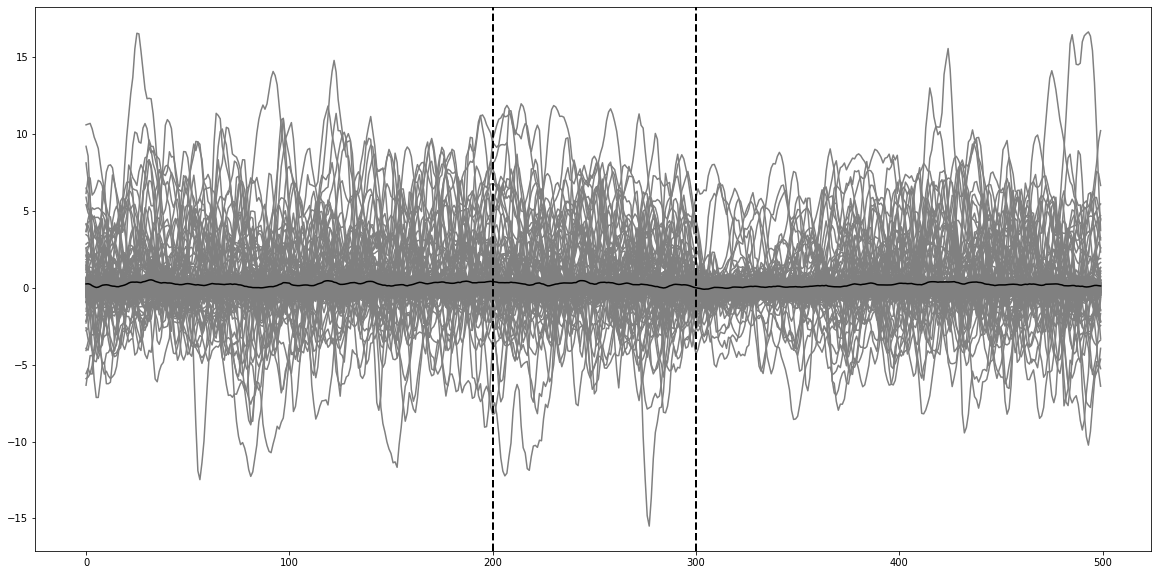

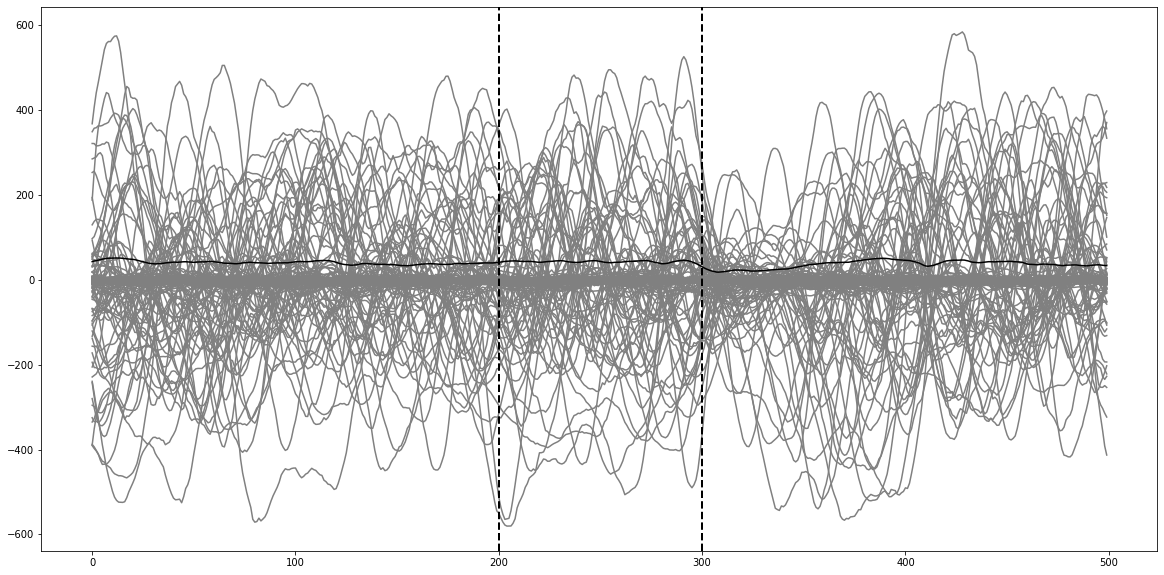

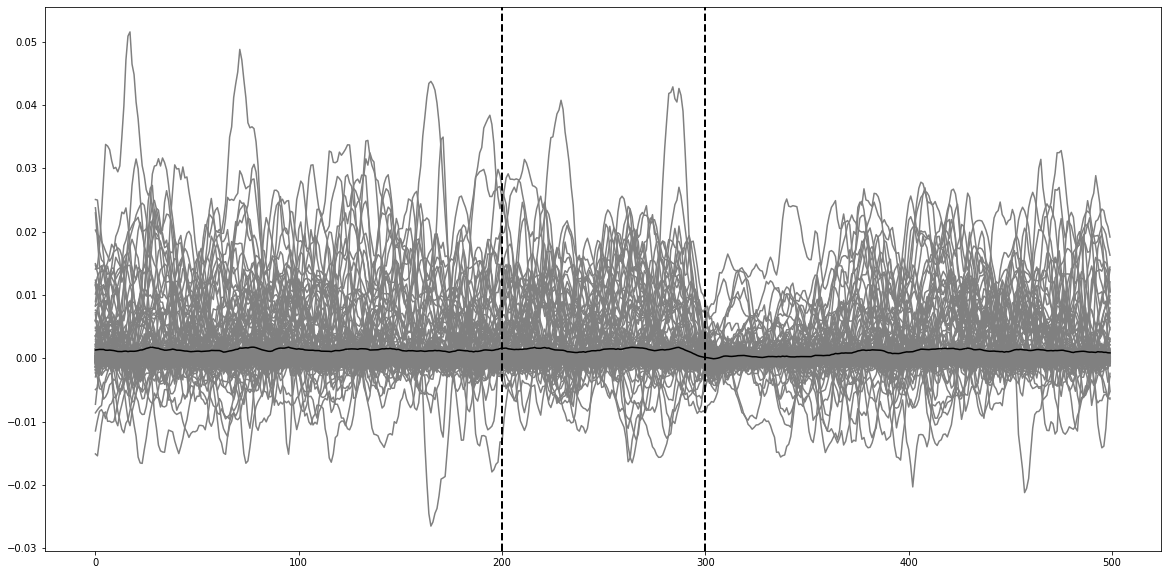

In [13]:
short=['Y', 'Z', 'X']
for s in short:
    fig, ax = plt.subplots(figsize=(20,10))
    plt.plot(all_behave_dict['250']['behavior'][s].T, c='Gray');
    if s=='Z':
        plt.plot(np.mean(np.abs(all_behave_dict['250']['behavior'][s]), axis=0).T, c='k');
    else:
        plt.plot(np.mean(all_behave_dict['250']['behavior'][s], axis=0).T, c='k');
    ax.axvline(200, linewidth=2, linestyle='--',c='k')
    ax.axvline(300, linewidth=2, linestyle='--',c='k')

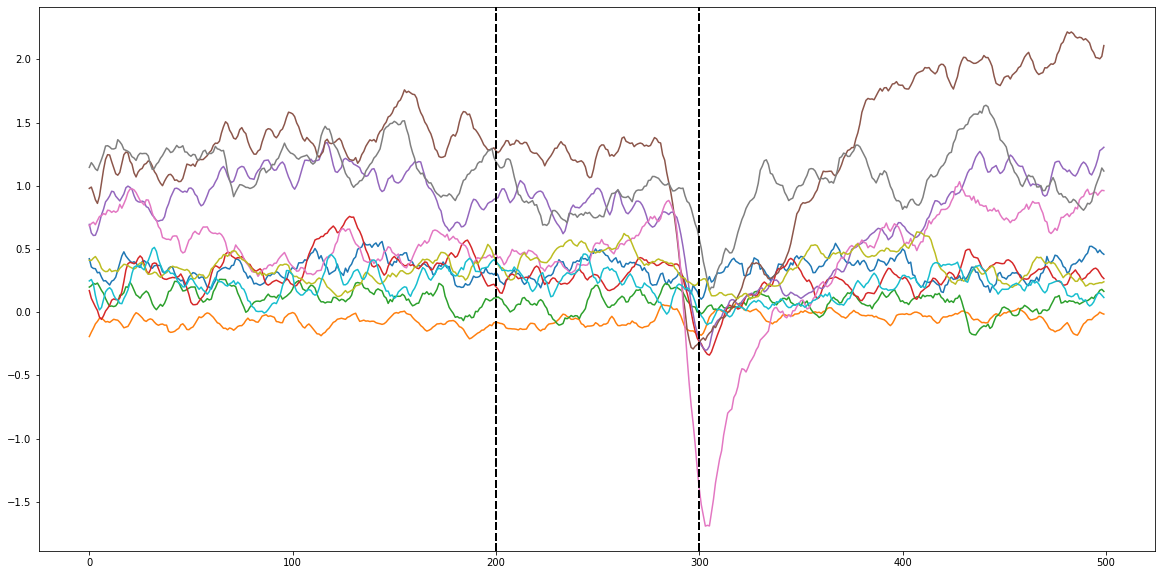

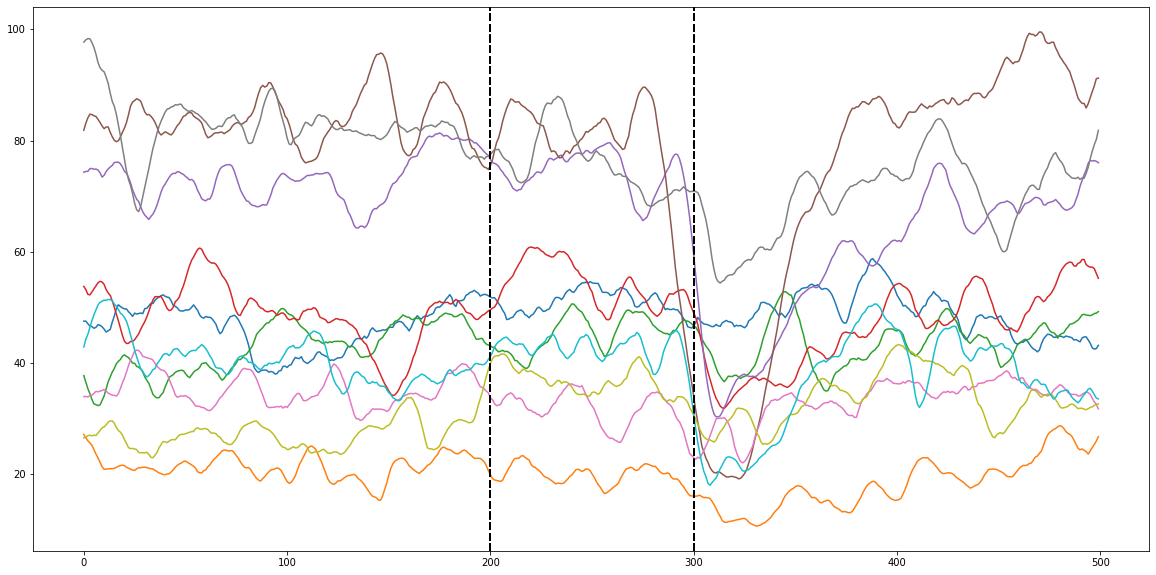

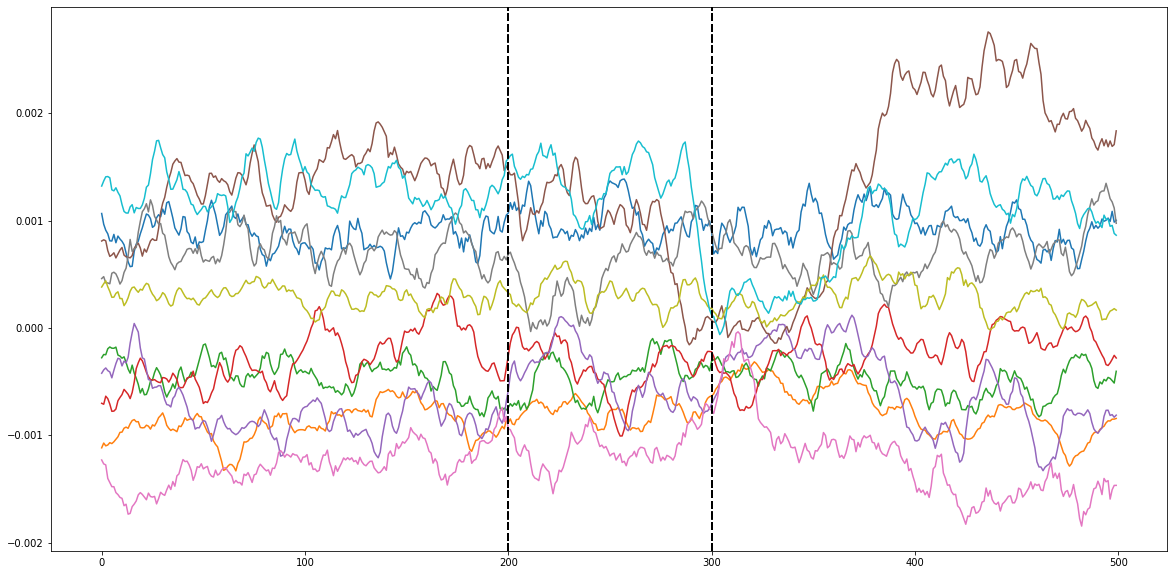

In [14]:
fly_nums=list(all_behave_dict.keys())
short=['Y', 'Z', 'X']
for s in short:
    fig, ax = plt.subplots(figsize=(20,10))
    for f in fly_nums:
#         print(f)
        if s=='Z':
            ax.plot(np.mean(np.abs(all_behave_dict[f'{f}']['behavior'][s]), axis=0).T);
        else:
            ax.plot(np.mean(all_behave_dict[f'{f}']['behavior'][s], axis=0).T);
        ax.axvline(200, linewidth=2, linestyle='--',c='k')
        ax.axvline(300, linewidth=2, linestyle='--',c='k')

In [15]:
print(all_behave_dict.keys())
print(all_behave_dict['226'].keys())
print(all_behave_dict['226']['behavior'].keys())

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['timestamps', 'event_times', 'behavior'])
dict_keys(['Y', 'Z', 'X'])


In [74]:
total=0
num=0
for fly in all_behave_dict:
    behavior=np.asarray(all_behave_dict[fly]['behavior']['Y'])
    print(behavior.shape, fly)
    for z,t in enumerate(behavior):
        total+=1
        new_t=np.array(t[200:300])
        for i in range(len(new_t)):
            if i <= len(new_t)-50:
#                 print(i)
#                 total+=1
                start=i
                end=i+50
                avg_move=np.abs(np.mean(t[start:end]))
                if avg_move>15:
                    num+=1
                    print(fly,z, avg_move)

print(f'total: {total}, num: {num}, percent of flying: {(num/total)*100}')


(198, 500) 226
(198, 500) 227
(197, 500) 228
(198, 500) 234
(199, 500) 239
(199, 500) 240
(198, 500) 241
(198, 500) 242
242 21 15.020275232099802
242 21 15.043799839325997
242 21 15.045179929385704
242 21 15.028893429837131
242 21 15.023240588565564
242 21 15.005961035488173
(198, 500) 249
(199, 500) 250
total: 1982, num: 6, percent of flying: 0.30272452068617556


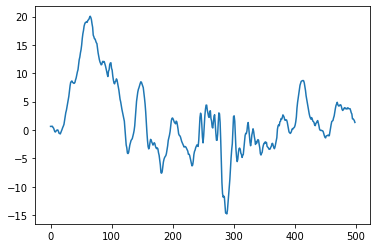

In [61]:
plt.plot(all_behave_dict['242']['behavior']['Y'][21,:]);

In [60]:
len(all_behave_dict[fly]['behavior']['Y'])

199

In [62]:
num=0
total=0
behave=all_behave_dict[fly]['behavior']['Y']
for j in range(len(behave)):
    test_trial=behave[j,:]
    for i in range(len(test_trial)):
        total+=1
        start=i
        end=i+50
        avg_move=np.mean(test_trial[start:end])
        if avg_move>=15:
            num+=1

In [63]:
print(num,total)
print(num/total)

0 99500
0.0


In [64]:
behaviors=['total', 'inc', 'dec', 'flat', 'non']
total_trials={}
raw_trials={}
pre_post={}
behave_lst={}
for b in behaviors:
    total_trials[b]={}
    raw_trials[b]={}
    pre_post[b]=[]
    for s in short:
        total_trials[b][s]=[] 
        raw_trials[b][s]=[] 

val_pos=0.1 #10 #
val_neg=-0.1 #-10 #
great_pos=1 #100 #
great_neg=-1 #-100 #
behave_set=all_behave_dict
for fly in behave_set:
    looms=behave_set[fly]['event_times']
    fly_Y=behave_set[fly]['behavior']['Y']
    fly_Z=behave_set[fly]['behavior']['Z']
    fly_behavior=behave_set[fly]['behavior']
    fly_raw=ft_raw[fly]
    behave_set[fly]['labels']=np.full(np.asarray(looms).shape,str)
#     print(np.asarray(fly_Y).shape)
#     print(np.asarray(looms).shape)
    behave_lst[fly]={'total':[],'label':[]}
    for i,trial in enumerate(fly_Y):
#         print(i)
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        pre_z=np.mean(fly_Z[i][150:200])
        post_z=np.mean(fly_Z[i][250:300])
        total_trials['total']['Y'].append(fly_behavior['Y'][i])
        total_trials['total']['Z'].append(fly_behavior['Z'][i])
        total_trials['total']['X'].append(fly_behavior['X'][i])
        raw_trials['total']['Y'].append(fly_raw['dRotLabY'][i])
        raw_trials['total']['Z'].append(fly_raw['dRotLabZ'][i])
        raw_trials['total']['X'].append(fly_raw['dRotLabX'][i])
        pre_post['total'].append([pre, post])
        behave_lst[fly]['total'].append([pre, post])
        if pre>val_neg and pre<val_pos and post>val_neg and post<val_pos:
            total_trials['flat']['Y'].append(fly_behavior['Y'][i])
            total_trials['flat']['Z'].append(fly_behavior['Z'][i])
            total_trials['flat']['X'].append(fly_behavior['X'][i])
            
            raw_trials['flat']['Y'].append(fly_raw['dRotLabY'][i])
            raw_trials['flat']['Z'].append(fly_raw['dRotLabZ'][i])
            raw_trials['flat']['X'].append(fly_raw['dRotLabX'][i])
            
            behave_set[fly]['labels'][i]='flat'
            x=np.mean(np.abs(fly_behavior['Z'][i]))
#             pre_post['flat'].append([pre_z, post_z, i,x])
            pre_post['flat'].append([pre, post, i,x])
            b='flat'
        elif post>np.abs(pre*2):
#         elif pre>great_neg and pre <val_pos and post>great_pos and post>np.abs(pre*2):
            total_trials['inc']['Y'].append(fly_behavior['Y'][i])
            total_trials['inc']['Z'].append(fly_behavior['Z'][i])
            total_trials['inc']['X'].append(fly_behavior['X'][i])
            
            raw_trials['inc']['Y'].append(fly_raw['dRotLabY'][i])
            raw_trials['inc']['Z'].append(fly_raw['dRotLabZ'][i])
            raw_trials['inc']['X'].append(fly_raw['dRotLabX'][i])
            
            behave_set[fly]['labels'][i]='inc'
            x=np.mean(np.abs(fly_behavior['Z'][i]))
#             pre_post['inc'].append([pre_z, post_z, i,x])
            pre_post['inc'].append([pre, post, i,x])
            b='inc'
        elif post<pre/2:
#         elif pre>great_pos and post<val_pos and post>great_neg and post<pre/2:
            total_trials['dec']['Y'].append(fly_behavior['Y'][i])
            total_trials['dec']['Z'].append(fly_behavior['Z'][i])
            total_trials['dec']['X'].append(fly_behavior['X'][i])
            
            raw_trials['dec']['Y'].append(fly_raw['dRotLabY'][i])
            raw_trials['dec']['Z'].append(fly_raw['dRotLabZ'][i])
            raw_trials['dec']['X'].append(fly_raw['dRotLabX'][i])
            
            behave_set[fly]['labels'][i]='dec'
            x=np.mean(np.abs(fly_behavior['Z'][i]))
#             pre_post['dec'].append([pre_z, post_z, i,x])
            pre_post['dec'].append([pre, post, i,x])
            b='dec'
                
        else:
            total_trials['non']['Y'].append(fly_behavior['Y'][i])
            total_trials['non']['Z'].append(fly_behavior['Z'][i])
            total_trials['non']['X'].append(fly_behavior['X'][i])
            
            raw_trials['non']['Y'].append(fly_raw['dRotLabY'][i])
            raw_trials['non']['Z'].append(fly_raw['dRotLabZ'][i])
            raw_trials['non']['X'].append(fly_raw['dRotLabX'][i])
            
            behave_set[fly]['labels'][i]='other'
            x=np.mean(np.abs(fly_behavior['Z'][i]))
#             pre_post['non'].append([pre_z, post_z, i,x])
            pre_post['non'].append([pre, post,i,x])
            b='non'
        behave_lst[fly]['label'].append(b)
    behave_lst[fly]['label']=np.asarray(behave_lst[fly]['label'])
    behave_lst[fly]['total']=np.asarray(behave_lst[fly]['total'])

In [65]:
for b in total_trials:
    print(f'{b}: {len(total_trials[b]["Y"])}')

total: 1982
inc: 386
dec: 697
flat: 526
non: 373


In [75]:
behave_set['242']['labels'][21]

'dec'

In [76]:
total_trials['dec'].keys()

dict_keys(['Y', 'Z', 'X'])

In [77]:
behaves=list(total_trials.keys())

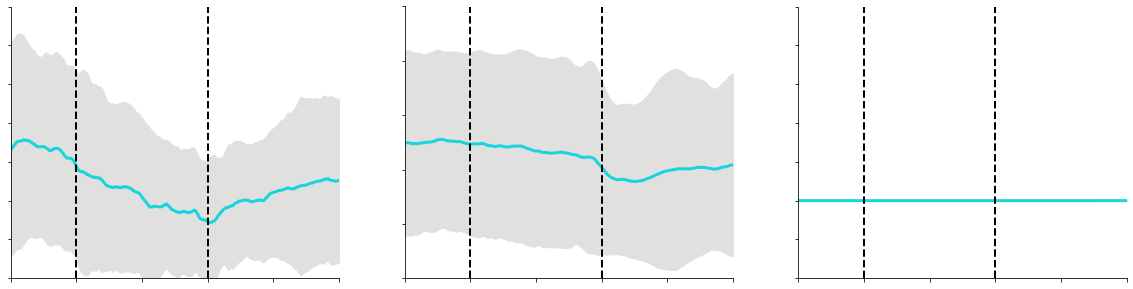

In [78]:
be='dec'
fig,axs=plt.subplots(nrows=1,ncols=len(short),figsize=(20,5))
for i,s in enumerate(short):
    if s=='Z':
        mean_trace=np.mean(np.abs(total_trials[be][s]), axis=0)
        std_trace=np.std(np.abs(total_trials[be][s]), axis=0)
    else:
        mean_trace=np.mean(total_trials[be][s], axis=0)
        std_trace=np.std(total_trials[be][s], axis=0)
    
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    if s!='Z':
        axs[i].set_ylim(-2, 5);
    if s=='Z':
        axs[i].set_ylim(-50, 200);
    axs[i].set_xlim(150, 400);
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
#     axs[i].tick_params(labelsize=20)
# plt.savefig(os.path.join(save_dir,f'{be}_avg_traces_YZX_ideal.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

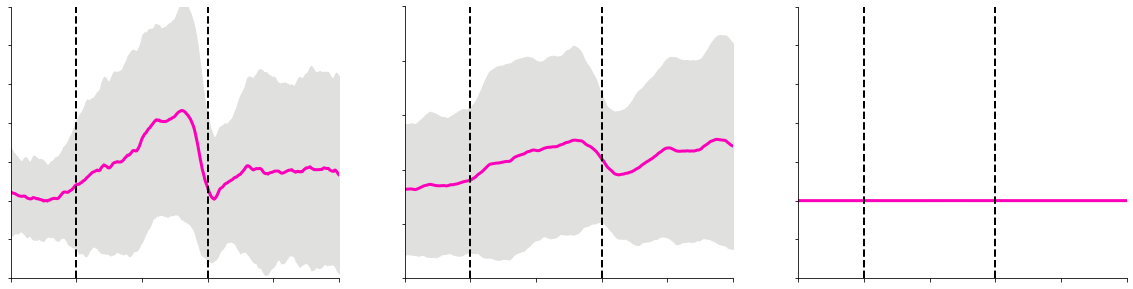

In [79]:
be='inc'
fig,axs=plt.subplots(nrows=1,ncols=len(short),figsize=(20,5))
for i,s in enumerate(short):
    if s=='Z':
        mean_trace=np.mean(np.abs(total_trials[be][s]), axis=0)
        std_trace=np.std(np.abs(total_trials[be][s]), axis=0)
    else:
        mean_trace=np.mean(total_trials[be][s], axis=0)
        std_trace=np.std(total_trials[be][s], axis=0)
    
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    if s!='Z':
        axs[i].set_ylim(-2, 5);
    if s=='Z':
        axs[i].set_ylim(-50, 200);
    axs[i].set_xlim(150, 400);
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
#     axs[i].tick_params(labelsize=20)
# plt.savefig(os.path.join(save_dir,f'{be}_avg_traces_YZX_ideal.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

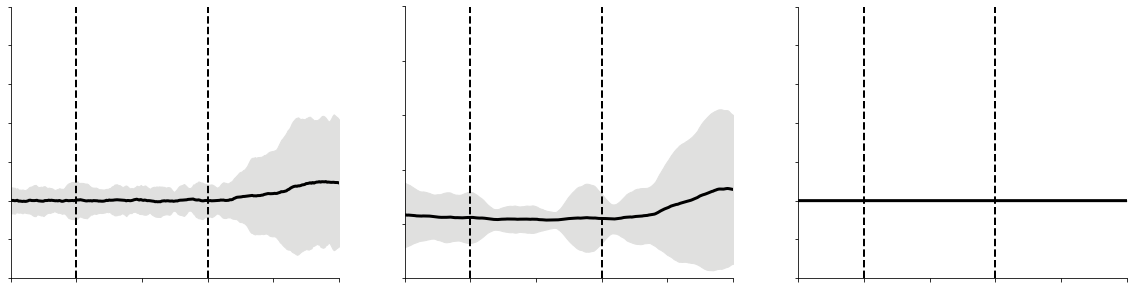

In [80]:
be='flat'
fig,axs=plt.subplots(nrows=1,ncols=len(short),figsize=(20,5))
for i,s in enumerate(short):
    if s=='Z':
        mean_trace=np.mean(np.abs(total_trials[be][s]), axis=0)
        std_trace=np.std(np.abs(total_trials[be][s]), axis=0)
    else:
        mean_trace=np.mean(total_trials[be][s], axis=0)
        std_trace=np.std(total_trials[be][s], axis=0)
    
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    if s!='Z':
        axs[i].set_ylim(-2, 5);
    if s=='Z':
        axs[i].set_ylim(-50, 200);
    axs[i].set_xlim(150, 400);
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
#     axs[i].tick_params(labelsize=20)
# plt.savefig(os.path.join(save_dir,f'{be}_avg_traces_YZX_ideal.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

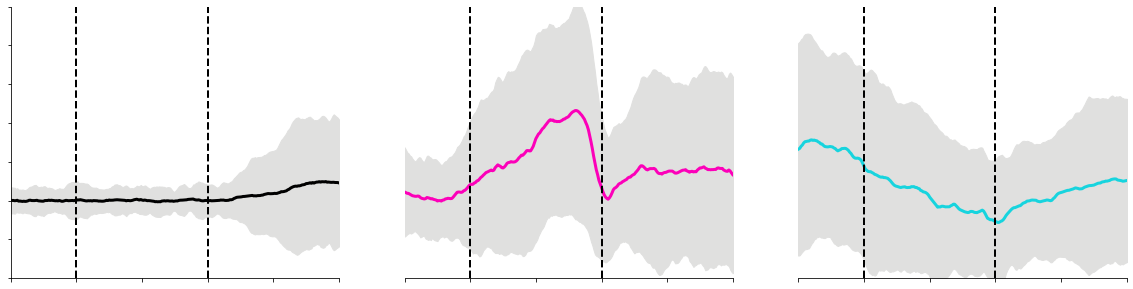

In [81]:
order=[ 'flat','inc', 'dec',]
fig,axs=plt.subplots(nrows=1,ncols=len(order),figsize=(20,5))
for i,be in enumerate(order):
    mean_trace=np.mean(total_trials[be]['Y'], axis=0)
    std_trace=np.std(total_trials[be]['Y'], axis=0)
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-2, 5);
    axs[i].set_xlim(150, 400);
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    if be!='flat':
        axs[i].spines['left'].set_visible(False)
        axs[i].set_yticks([])

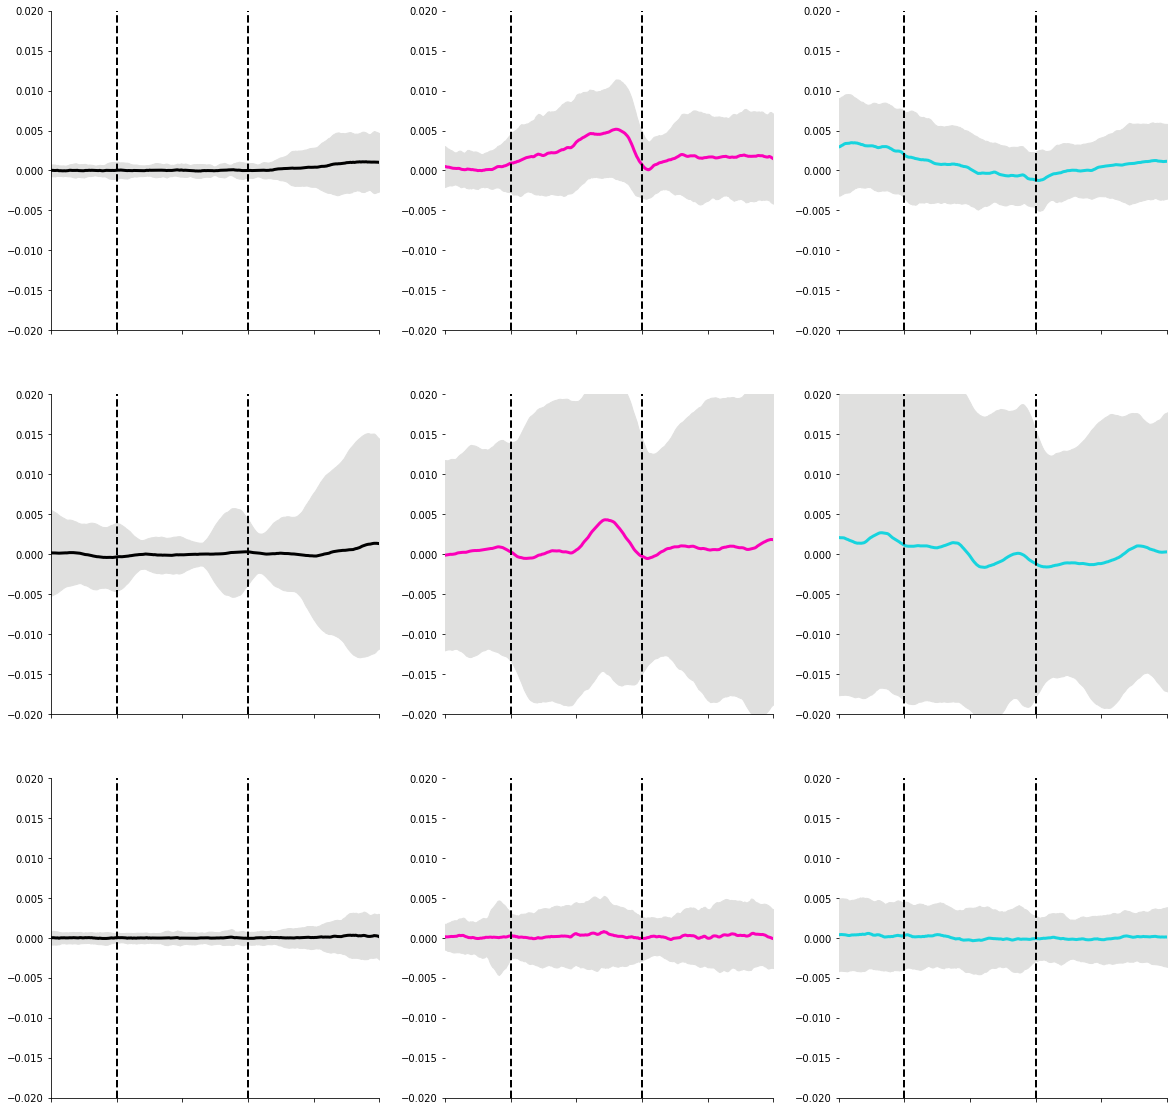

In [82]:
order=[ 'flat','inc', 'dec',]
fig,axs=plt.subplots(nrows=len(short),ncols=len(order),figsize=(20,20))
for j,s in enumerate(short):
    for i,be in enumerate(order):
        mean_trace=np.mean(raw_trials[be][s], axis=0)
        std_trace=np.std(raw_trials[be][s], axis=0)
        axs[j,i].plot(mean_trace, color=behavior_colors[be],lw=3)
        axs[j,i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
        axs[j,i].axvline(200, linewidth=2, linestyle='--', color='k')
        axs[j,i].axvline(300, linewidth=2, linestyle='--', color='k')
        axs[j,i].set_ylim(-0.02, 0.02);
        axs[j,i].set_xlim(150, 400);
        axs[j,i].set_xticklabels([])
#         axs[j,i].set_yticklabels([])
        axs[j,i].spines['top'].set_visible(False)
        axs[j,i].spines['right'].set_visible(False)
        if be!='flat':
            axs[j,i].spines['left'].set_visible(False)
#             axs[j,i].set_yticks([])

In [83]:
target_variance=np.var(np.asarray(total_trials['flat']['Y'])[:,150:200], axis=0)
arr=np.asarray(total_trials['inc']['Y'])[:,150:200]
tolerance=0.1

In [84]:
be='flat'
mean_trace=np.mean(total_trials[be]['Y'], axis=0)[150:200]
std_trace=np.std(total_trials[be]['Y'], axis=0)[150:200]

In [85]:
print(target_variance.shape)
print(arr.shape)

(50,)
(386, 50)


In [86]:
def rank_by_internal_variance(arr, axis=1):
    """
    Rank by the variance within each element (row).
    High internal variance = more spread in that row.
    """
    arr = np.array(arr)
    
    # Variance of each row
    row_variances = np.var(arr, axis=axis)
    
    # Sort by variance (descending)
    rankings = np.argsort(row_variances)[::-1]
    
    return rankings, row_variances

rankings, variances = rank_by_internal_variance(arr)

print("Top 10 by internal variance:")
for i in range(10):
    idx = rankings[i]
    print(f"  Row {idx}: variance = {variances[idx]:.6f}")

Top 10 by internal variance:
  Row 369: variance = 17.005849
  Row 292: variance = 13.877698
  Row 118: variance = 11.669055
  Row 264: variance = 11.171409
  Row 285: variance = 10.806424
  Row 320: variance = 10.125561
  Row 140: variance = 8.588277
  Row 95: variance = 7.761441
  Row 291: variance = 7.492436
  Row 297: variance = 7.106353


In [87]:
np.std(np.asarray(total_trials['inc']['Y'])[:,150:200][rankings[70:],:])

0.6147132962189539

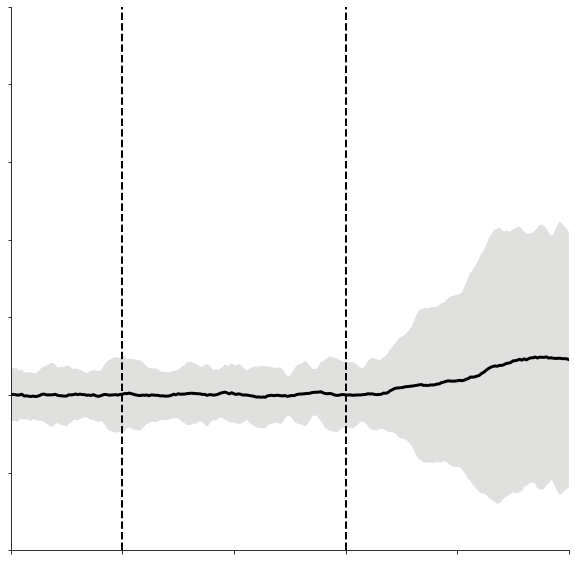

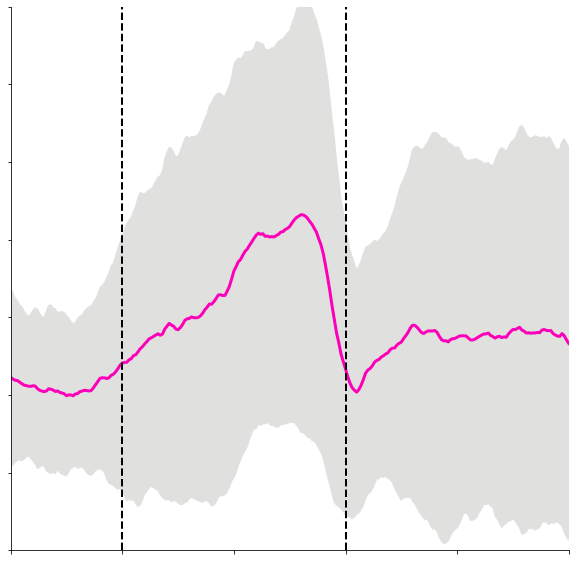

In [88]:
event1='subsamp_inc'
s='Y'
fig,axs=plt.subplots(figsize=(10,10))
be='flat'
mean_trace=np.mean(total_trials[be][s], axis=0)
std_trace=np.std(total_trials[be][s], axis=0)
axs.plot(mean_trace, color=behavior_colors[be],lw=3)
axs.fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs.axvline(200, linewidth=2, linestyle='--', color='k')
axs.axvline(300, linewidth=2, linestyle='--', color='k')
axs.set_ylim(-2, 5);
axs.set_xlim(150, 400);
axs.set_xticklabels([])
axs.set_yticklabels([])
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'trace_{be}_{event1}.png'), dpi=300, bbox_inches='tight')
fig,axs=plt.subplots(figsize=(10,10))
be='inc'
mean_trace=np.mean(total_trials[be][s], axis=0)
std_trace=np.std(total_trials[be][s], axis=0)
axs.plot(mean_trace, color=behavior_colors[be],lw=3)
axs.fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs.axvline(200, linewidth=2, linestyle='--', color='k')
axs.axvline(300, linewidth=2, linestyle='--', color='k')
axs.set_ylim(-2, 5);
axs.set_xlim(150, 400);
axs.set_xticklabels([])
axs.set_yticklabels([])
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'trace_{be}_{event1}.png'), dpi=300, bbox_inches='tight')

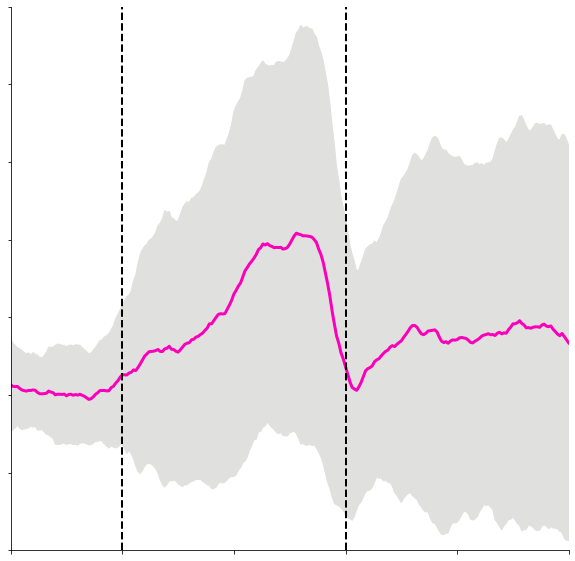

In [89]:
event1='subsamp_inc_lowest'
s='Y'
fig,axs=plt.subplots(figsize=(10,10))
be='inc'
mean_trace=np.mean(np.asarray(total_trials[be][s])[rankings[70:],:], axis=0)
std_trace=np.std(np.asarray(total_trials[be][s])[rankings[70:],:], axis=0)
axs.plot(mean_trace, color=behavior_colors[be],lw=3)
axs.fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
axs.axvline(200, linewidth=2, linestyle='--', color='k')
axs.axvline(300, linewidth=2, linestyle='--', color='k')
axs.set_ylim(-2, 5);
axs.set_xlim(150, 400);
axs.set_xticklabels([])
axs.set_yticklabels([])
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'trace_{be}_{event1}.png'), dpi=300, bbox_inches='tight')

In [90]:
behave_set['250'].keys()

dict_keys(['timestamps', 'event_times', 'behavior', 'labels'])

In [91]:
behave_set['250']['behavior']['Y'].shape

(199, 500)

In [92]:
np.unique(behave_set['250']['labels'])

array(['dec', 'flat', 'inc', 'other'], dtype=object)

In [93]:
labs=np.unique(behave_set['250']['labels'])
types={}
for b in labs:
    types[b]={}
    for be in labs:
        types[b][be]=0
    types[b]['total']=0

In [94]:
for fly in behave_set:
    if fly!='227':
        fly_behaves=behave_set[fly]['labels']
        for i,trial in enumerate(fly_behaves):
#             print(trial)
            types[trial]['total']+=1
            if i+2<fly_behaves.shape[0]:
                next_type=fly_behaves[i+1]
#                 print(next_type)
                types[trial][next_type]+=1

In [95]:
def make_types_count(behave_set, start=None,end=None, remove=None):
    key=np.array(list(behave_set.keys()))[-1]
    labs=np.unique(behave_set[key]['labels'])
    if remove!=None:
        labs=labs[labs!=remove]
    print(labs)
    types={}
    for b in labs:
        types[b]={}
        for be in labs:
            types[b][be]=0
        types[b]['total']=0
    for fly in behave_set:
        if fly!='227':
            if start==None and end==None:
                fly_behaves=behave_set[fly]['labels']
            else:
                fly_behaves=behave_set[fly]['labels'][start:end]
            for i,trial in enumerate(fly_behaves):
                if remove!=None and trial==remove:
                    continue
                else:
                    types[trial]['total']+=1
                    if i+1<fly_behaves.shape[0]:
                        next_type=fly_behaves[i+1]
                        if remove!=None and next_type==remove:
                            continue
                        else:
                            types[trial][next_type]+=1
    return types

In [96]:
types=make_types_count(behave_set)

['dec' 'flat' 'inc' 'other']


In [97]:
types_2={}
labels=[]
for b in types:
    types_2[b]=[]
    for be in types[b]:
        if be!='total':
            labels.append(be)
            per=types[b][be]/types[b]['total']
            types_2[b].append(per)
labels=np.unique(labels)

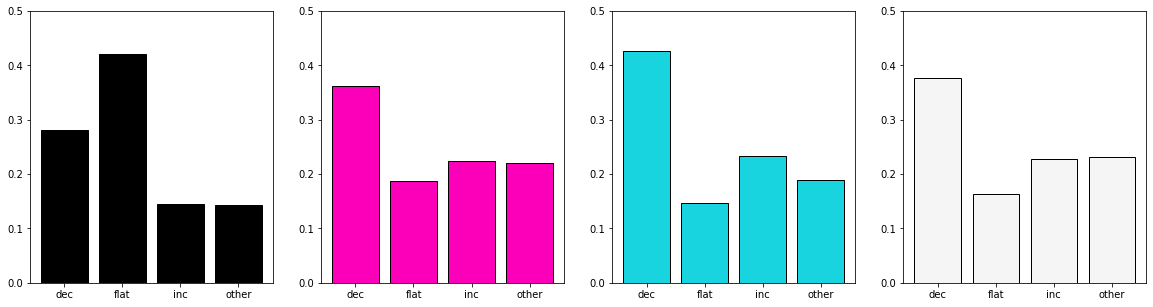

In [98]:
fig,axs=plt.subplots(nrows=1,ncols=4,figsize=(20,5))
be='flat'
axs[0].bar(labels,types_2[be],color=behavior_colors[be],edgecolor='k');
axs[0].set_ylim(0, 0.5);
be='inc'
axs[1].bar(labels,types_2[be],color=behavior_colors[be],edgecolor='k');
axs[1].set_ylim(0, 0.5);
be='dec'
axs[2].bar(labels,types_2[be],color=behavior_colors[be],edgecolor='k');
axs[2].set_ylim(0,0.5);
be='other'
axs[3].bar(labels,types_2[be],color=behavior_colors[be],edgecolor='k');
axs[3].set_ylim(0, 0.5);

In [99]:
prestim_Y_mean=[]
trial_lab=[]
for fly in behave_set:
    prestim_Y=np.asarray(behave_set[fly]['behavior']['Y'])[:,150:200]
    prestim_Y_mean.append(np.mean(prestim_Y,axis=-1))
    trial_lab.append(behave_set[fly]['labels'])
pym=np.hstack(prestim_Y_mean)
tl=np.hstack(trial_lab)

In [100]:
sort_idx=np.argsort(pym)
sort_pym=pym[sort_idx]
sort_tl=tl[sort_idx]
point_colors = [behavior_colors[label] for label in sort_tl]

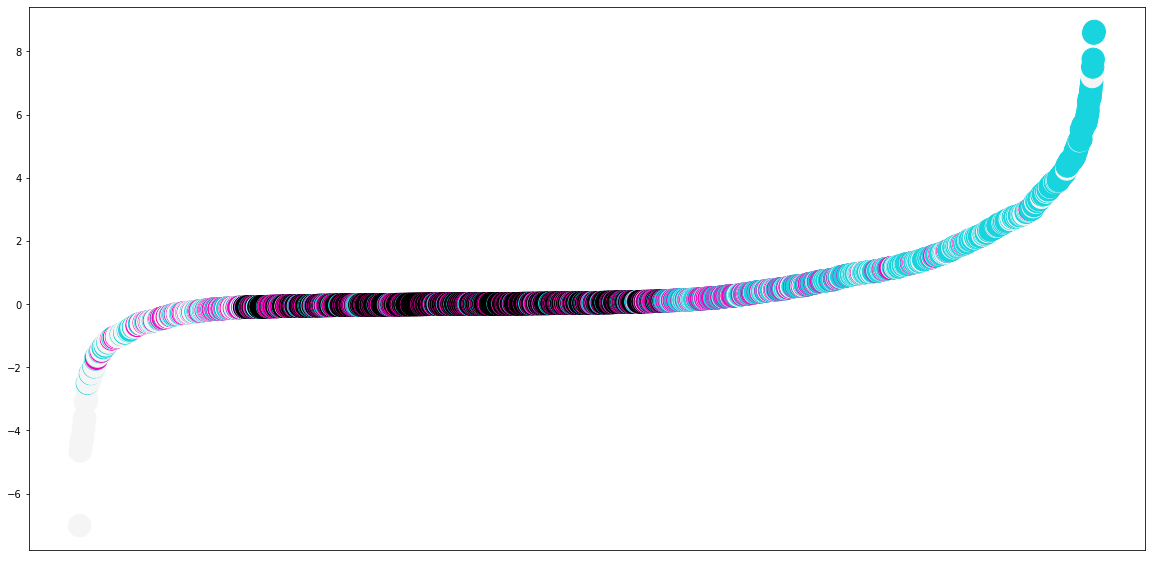

In [101]:
fig,axs=plt.subplots(figsize=(20,10))
axs.scatter(range(len(sort_pym)), sort_pym,s=500,c=point_colors);
axs.set_xticks([]);

In [102]:
def make_snakey_plot(types):
    labels = list(types.keys())      # your state order
    n = len(labels)

    # indices for duplicated nodes
    idx_from = {lab: i for i, lab in enumerate(labels)}        # 0..n-1
    idx_to   = {lab: i + n for i, lab in enumerate(labels)}    # n..2n-1

    sources, targets, values, link_colors = [], [], [], []

    for frm, arr in types.items():
        for to, v in arr.items():
            if frm!='total' and to!='total':
                sources.append(idx_from[frm])        # left column
                targets.append(idx_to[to])           # right column
                values.append(v)
                link_colors.append(behavior_colors[frm])  # color by FROM

    # Force a 2-column layout (left = From, right = To)
    x = [0.02]*n + [0.98]*n
    y = list(np.linspace(0.02, 0.98, n)) + list(np.linspace(0.02, 0.98, n))

    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=5,
            thickness=20,
            line=dict(color="black", width=0.3),  # duplicated labels
            color=[behavior_colors[l] for l in labels] + [behavior_colors[l] for l in labels],
            x=x, y=y
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
            line=dict(color="black", width=0.3)
        )
    ))

    # fig.update_layout(title="Transitions", font_size=16)
    return fig

In [103]:
types_start=make_types_count(behave_set,start=-51,end=-1)
fig2=make_snakey_plot(types_start)
fig2.show()

['dec' 'flat' 'inc' 'other']


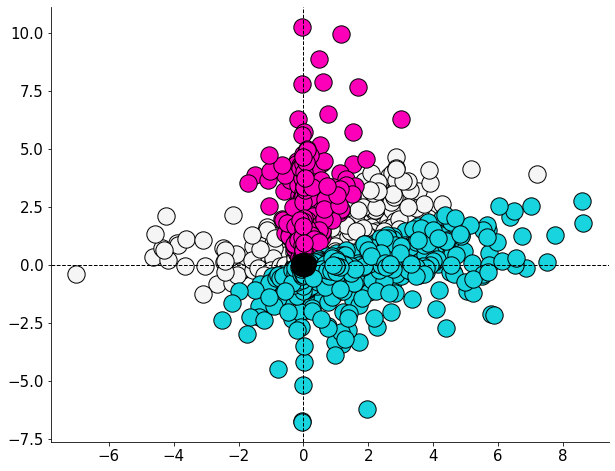

In [104]:
fig,ax=plt.subplots(figsize=(10, 8))
behavior_set=pre_post
order=['non','inc','dec','flat']
# order=['total']
for key in order:
    ax.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=300,color=behavior_colors[key], edgecolor='k', label=key);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
# ax.set_xticklabels([]);
# ax.set_yticklabels([]);
# ax.set_xlim(-8,11)
# ax.set_ylim(-8,11)
plt.axvline(0,color='k',linestyle='--',lw=1);
plt.axhline(0,color='k',linestyle='--',lw=1);
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

In [105]:
def blend_with_white(hex_color, t):
    """
    t in [0,1]: 0 -> original color, 1 -> white
    """
    rgb = np.array(mcolors.to_rgb(hex_color))
    white = np.array([1., 1., 1.])
    return (1 - t) * rgb + t * white

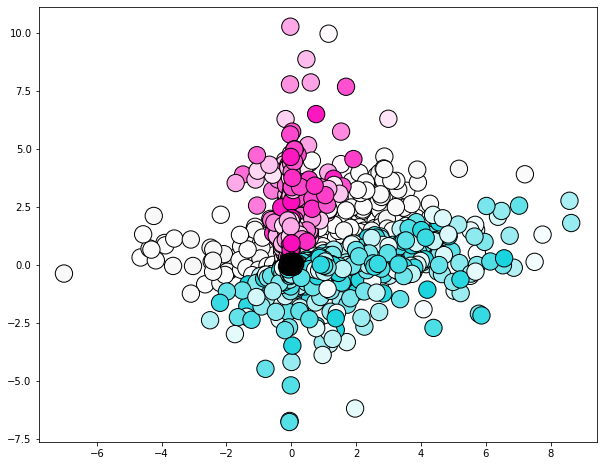

In [106]:
fig, ax = plt.subplots(figsize=(10, 8))

behavior_set = pre_post
order = ['non', 'inc', 'dec', 'flat']

for key in order:
    arr = np.asarray(behavior_set[key])  # columns: x, y, trial
    x, y, trial = arr[:, 0], arr[:, 1], arr[:, 2]
    # map trial 1..200 -> whiteness 1..0 (trial=1 is lightest)
    w = 1 - (trial - 1) / (np.max(trial) - 1)          # w in [0,1]
    # optional: don’t wash out completely
    w = 0.99 * w

    colors = [blend_with_white(behavior_colors[key], wi) for wi in w]

    ax.scatter(x, y, s=300, c=colors, edgecolor='k', label=key)

plt.show()

non: max 0.9801544945474413,min 0.0, mean 0.7362966282957546, median 0.7572855486522195
inc: max 0.9775434780843899,min 0.0, mean 0.634652651473778, median 0.6517628220501084
dec: max 0.9864702985645454,min 0.0, mean 0.6884757232798334, median 0.7164293513099013
flat: max 0.9935222466786122,min 0.0, mean 0.8127430580140973, median 0.885802555528124


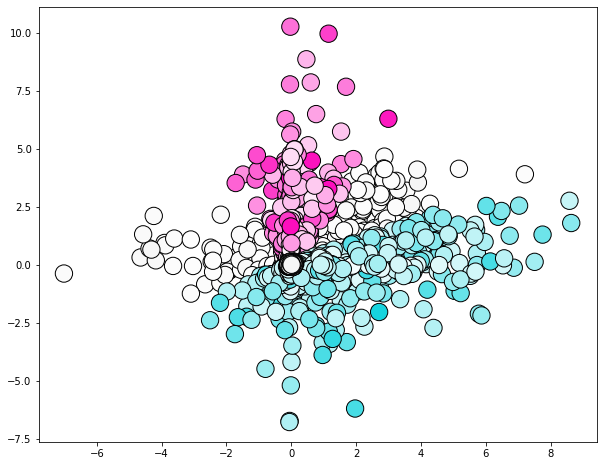

In [107]:
fig, ax = plt.subplots(figsize=(10, 8))

behavior_set = pre_post
order = ['non', 'inc', 'dec', 'flat']

for key in order:
    arr = np.asarray(behavior_set[key])  # columns: x, y, trial
    x, y, trial = arr[:, 0], arr[:, 1], arr[:, 3]       # w in [0,1]
    # map trial 1..200 -> whiteness 1..0 (trial=1 is lightest)
    w = 1 - (trial - 1) / (np.max(trial) - 1)          # w in [0,1]
    # optional: don’t wash out completely
    w = 0.99 * w
    print(f'{key}: max {np.max(w)},min {np.min(w)}, mean {np.mean(w)}, median {np.median(w)}')

    colors = [blend_with_white(behavior_colors[key], wi) for wi in w]

    ax.scatter(x, y, s=300, c=colors, edgecolor='k', label=key)

plt.show()

In [108]:
trial_count_lst=[]
b_val={'inc':1,'dec':-1,'flat':0,'non':2}
for fly in behave_lst:
    labels=behave_lst[fly]['label'][:least]
    be=np.unique(labels)
    flies=np.full(least,np.nan)
    for b in be:
        flies[labels==b]=b_val[b]
    trial_count_lst.append(flies)
trial_count_lst=np.asarray(trial_count_lst)   

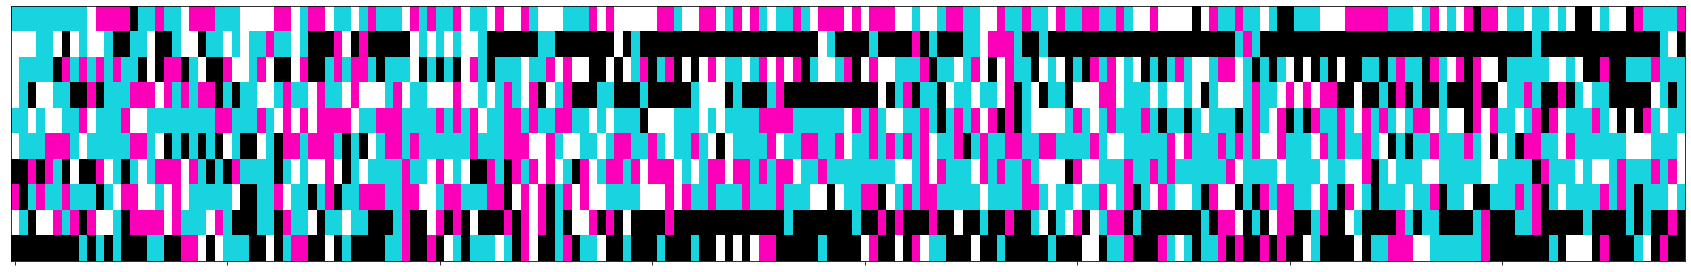

In [110]:
colors=['#17D4DE', 'k', '#FC00B9','w']
cmap=matplotlib.colors.ListedColormap(colors)
fig,ax=plt.subplots(figsize=(30,30))
im=ax.imshow(trial_count_lst, cmap=cmap)
ax.set_yticks([]);
ax.set_xticklabels([]);
ax.set_aspect(3)
ax.tick_params(axis='x', labelsize=40)
# plt.savefig(os.path.join(save_dir,'total_behavior_heatmap.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# plt.savefig(os.path.join(save_dir,'total_behavior_heatmap.png'), dpi=300, bbox_inches='tight')
